## Grad-CAM Visualization

In [ ]:
# 📦 Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [ ]:
train_csv_path = '/kaggle/input/rsna-bone-age/boneage-training-dataset.csv'
test_csv_path = '/kaggle/input/rsna-bone-age/boneage-test-dataset.csv'
train_img_dir = '/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset'
test_img_dir = '/kaggle/input/rsna-bone-age/boneage-test-dataset/boneage-test-dataset'

In [ ]:
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
train_df.columns
test_df.columns

In [ ]:
train_df['path'] = train_df['id'].astype(str) + '.png'
test_df['path'] = test_df['Case ID'].astype(str) + '.png'

In [ ]:
mean_boneage = train_df['boneage'].mean()
std_boneage = train_df['boneage'].std()
train_df['boneage_z'] = (train_df['boneage'] - mean_boneage) / std_boneage
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42)

In [ ]:
# 📦 Imports
import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For Grad-CAM
from tensorflow.keras import backend as K

2025-08-28 03:55:58.306018: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756353358.654534      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756353358.750773      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/tmp/ipykernel_36/3253644031.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap("jet")


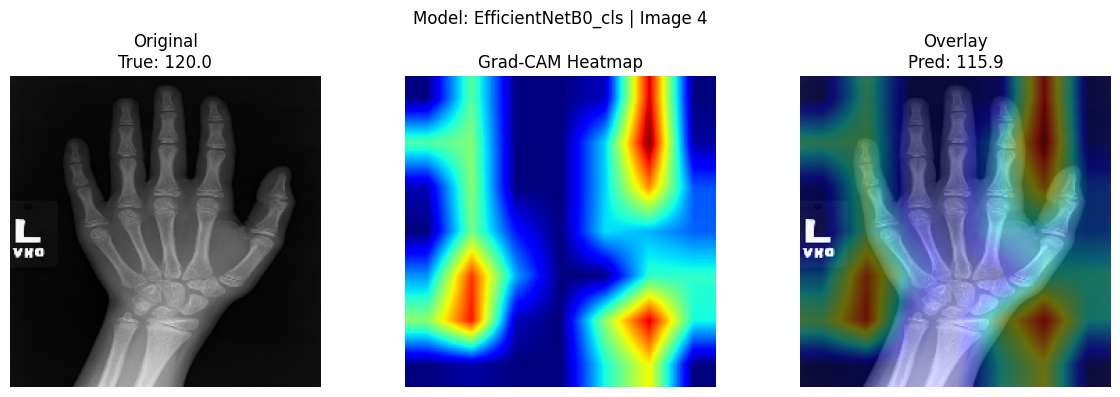

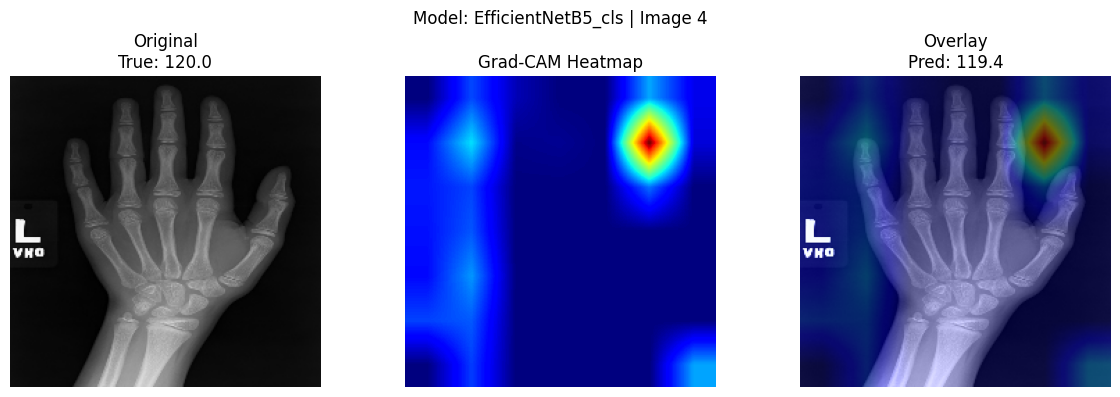

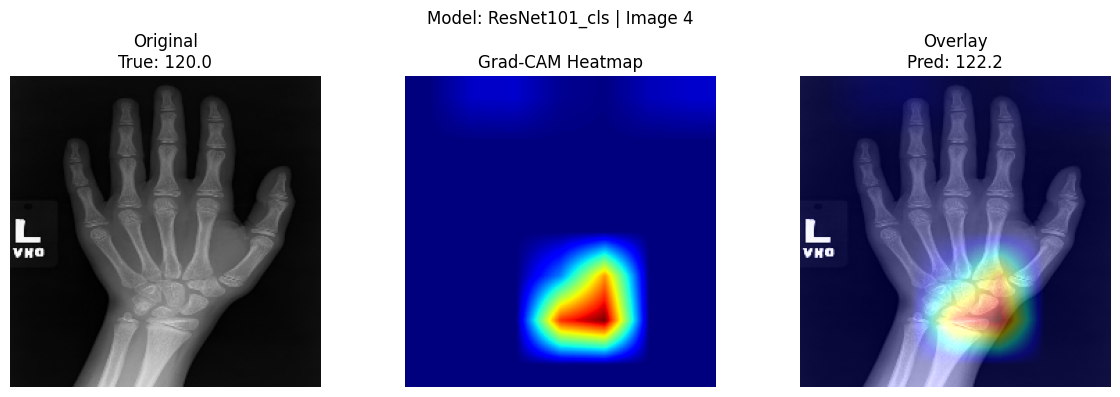

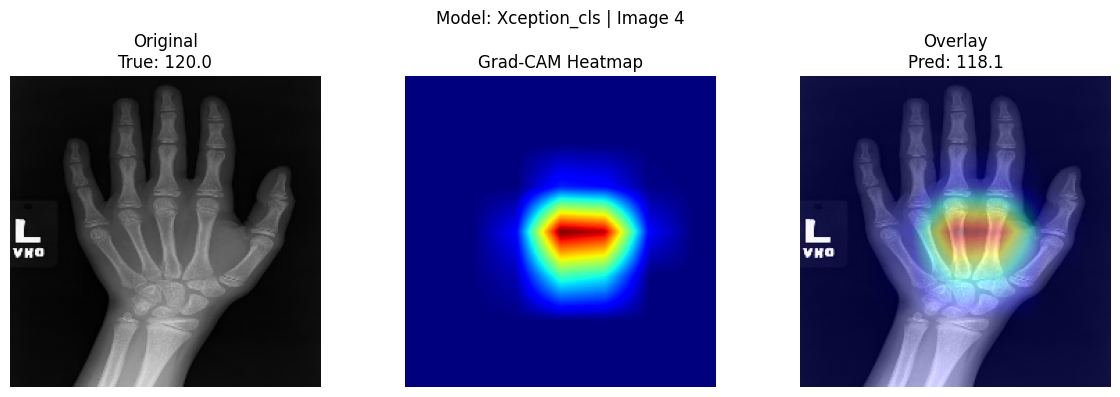

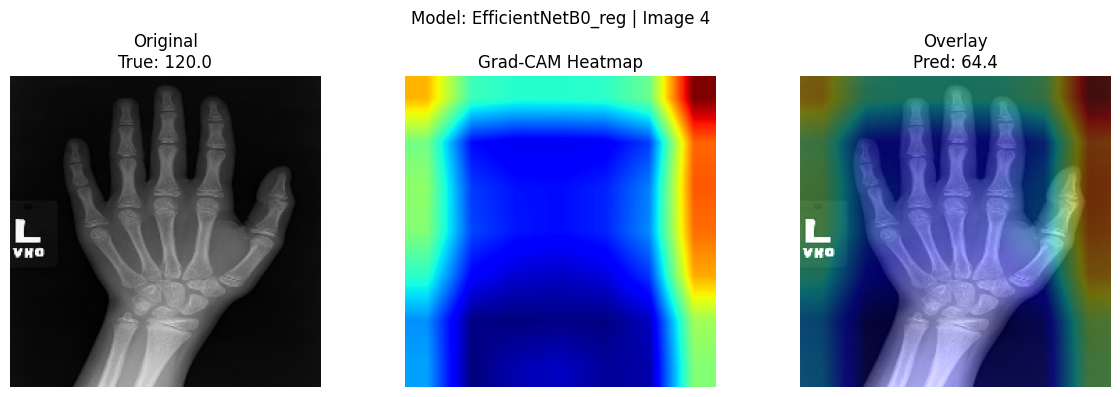

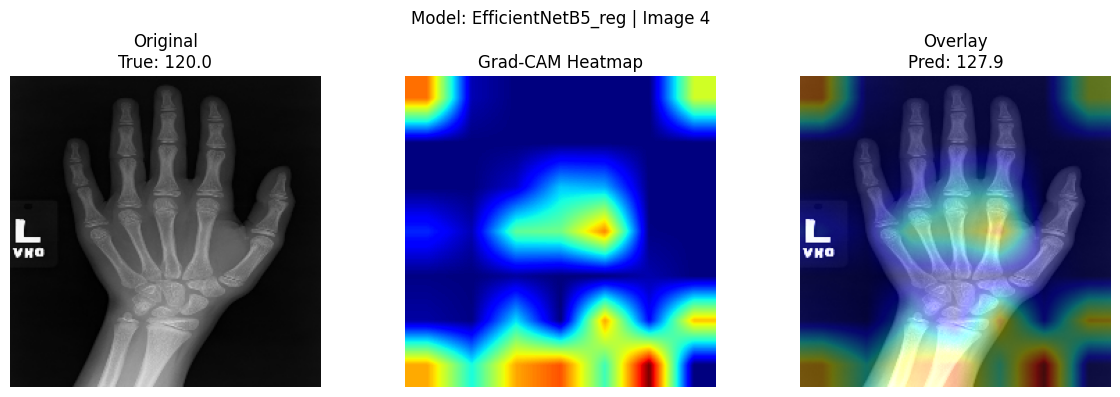

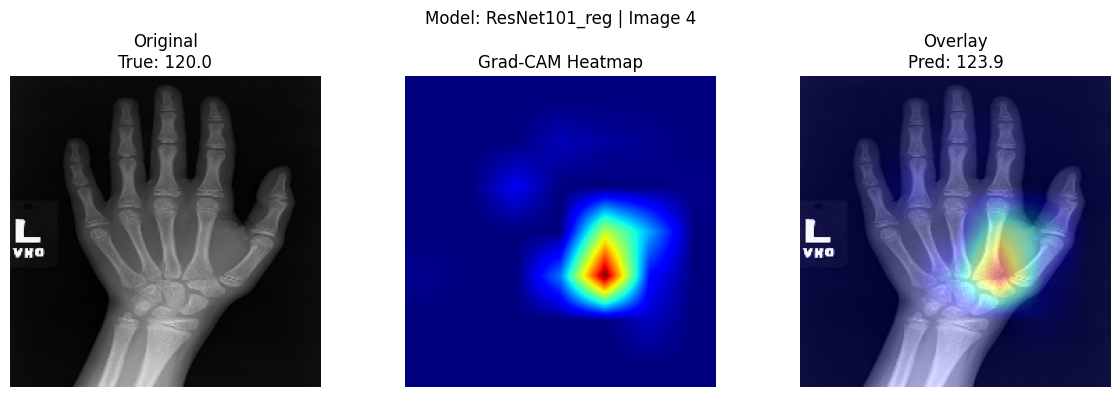

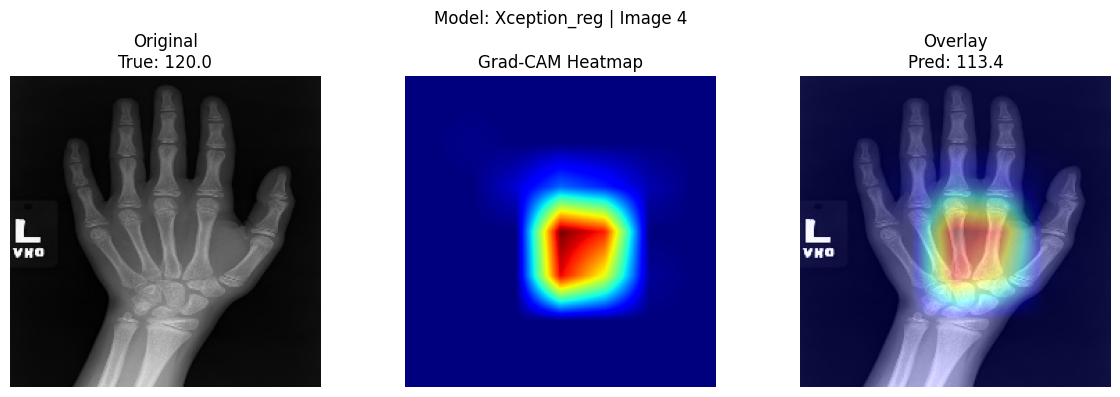

In [ ]:
# 📦 Imports
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import RootMeanSquaredError

# ⚙️ Grad-CAM function
def get_gradcam(model, img_array, gender_array, layer_name=None):
    if layer_name is None:
        # Get last conv layer
        conv_layers = [layer.name for layer in model.layers if 'conv' in layer.name]
        if not conv_layers:
            raise ValueError("⚠️ No conv layers found in model!")
        layer_name = conv_layers[-1]

    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([img_array, gender_array])
        loss = predictions[0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), predictions.numpy()[0][0]

# 📂 List of models
model_paths = {
    "EfficientNetB0_cls": "/kaggle/input/outputs/keras/default/1/EffecientNetB0/EffecientnetB0.keras",
    "EfficientNetB5_cls": "/kaggle/input/outputs/keras/default/1/EfficientNetB5/EfficientnetB5.keras",
    "ResNet101_cls": "/kaggle/input/outputs/keras/default/1/ResNet101/Resnet101.keras",
    "Xception_cls": "/kaggle/input/outputs/keras/default/1/Xception/Xception.keras",
    "EfficientNetB0_reg": "/kaggle/input/outputs/keras/default/1/EffecientNetB0/EffecientnetB0_Reg.keras",
    "EfficientNetB5_reg": "/kaggle/input/outputs/keras/default/1/EfficientNetB5/EfficientnetB5_reg.keras",
    "ResNet101_reg": "/kaggle/input/outputs/keras/default/1/ResNet101/Resnet101_reg.keras",
    "Xception_reg": "/kaggle/input/outputs/keras/default/1/Xception/Xception_reg.keras",
}

# 📊 Loop through models
for model_name, model_path in model_paths.items():
    # print(f"\n🔹 Processing Model: {model_name}")
    
    # Load model
    model = load_model(model_path, compile=False)
    model.compile(optimizer='adam', loss='mse',
                  metrics=['mae', RootMeanSquaredError(name='rmse')])
    
    # Grad-CAM for first 5 validation images
    for idx in range(3,4):
        row = val_data.iloc[idx]
        img_path = os.path.join(train_img_dir, row['path'])

        # Preprocess image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (224, 224))
        img = img.astype("float32") / 255.0
        img = np.expand_dims(img, axis=-1)
        img = np.repeat(img, 3, axis=-1)  # RGB
        input_img = np.expand_dims(img, axis=0)

        gender = np.array(row['male']).reshape(1, 1)

        # Get Grad-CAM
        heatmap, pred_age_z = get_gradcam(model, input_img, gender)
        pred_age = (pred_age_z * std_boneage) + mean_boneage
        true_age = row['boneage']

        # Resize & overlay
        heatmap = cv2.resize(heatmap, (224, 224))
        heatmap = np.uint8(255 * heatmap)
        jet = cm.get_cmap("jet")
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[heatmap]
        overlay = jet_heatmap * 0.4 + img / np.max(img)

        # Plot
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        ax[0].imshow(img, cmap="gray")
        ax[0].set_title(f"Original\nTrue: {true_age:.1f}")
        ax[0].axis("off")

        ax[1].imshow(heatmap, cmap="jet")
        ax[1].set_title("Grad-CAM Heatmap")
        ax[1].axis("off")

        ax[2].imshow(overlay)
        ax[2].set_title(f"Overlay\nPred: {pred_age:.1f}")
        ax[2].axis("off")

        plt.suptitle(f"Model: {model_name} | Image {idx+1}", fontsize=12)
        plt.tight_layout()
        plt.show()
